In [1]:
import sys
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
from folium.plugins import Draw

# Insert repo root directory into notebook path to allow for import with the repo directory
repository_root = Path.cwd().parent.parent.resolve()
sys.path.insert(0, str(repository_root))

from src.config.config import resolved_config

In [2]:
# Instantiate path to base data shapefile
shapefile_path = resolved_config.dataset.raw_dataset.base_data

In [3]:
# load data
administrative_boundaries = gpd.read_file(shapefile_path)
administrative_boundaries.head(2)

,globalid,uniq_id,timestamp,editor,wardname,wardcode,lganame,lgacode,statename,statecode,amapcode,status,source,urban,geometry
0,564c8211-f688-4091-b45e-a2862ddcfb54,499246,2020-08-31,najib.adam,Ikuru,RVSNDN06,Andoni,33005,Rivers,RI,NIE RVS NDN,Operational Placeholder,INEC,No,"POLYGON ((7.39065 4.43648, 7.38503 4.4791, 7.3..."
1,a3a0fa0f-b22c-4085-9bdb-1e1c3473d79a,499247,2019-03-16,oluseye.abraham,Aktward 17,RVSABM17,Akuku Toru,33004,Rivers,RI,NIE RVS ABM,Operational Placeholder,INEC,No,"POLYGON ((6.71866 4.61093, 6.71477 4.6205, 6.7..."


In [4]:
# Display the datatypes of the geopandas dataframe
administrative_boundaries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9410 entries, 0 to 9409
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   globalid   9410 non-null   str           
 1   uniq_id    9410 non-null   int64         
 2   timestamp  9410 non-null   datetime64[ms]
 3   editor     9410 non-null   str           
 4   wardname   9410 non-null   str           
 5   wardcode   9410 non-null   str           
 6   lganame    9410 non-null   str           
 7   lgacode    9410 non-null   str           
 8   statename  9410 non-null   str           
 9   statecode  9410 non-null   str           
 10  amapcode   7951 non-null   str           
 11  status     9410 non-null   str           
 12  source     9410 non-null   str           
 13  urban      9410 non-null   str           
 14  geometry   9308 non-null   geometry      
dtypes: datetime64[ms](1), geometry(1), int64(1), str(12)
memory usage: 1.1 MB


In [5]:
# Filter and create a dataframe based on the ward/location of interest
ward_boundaries = (
    administrative_boundaries.loc[(administrative_boundaries['wardname'] == "Umagbae South")&
    (administrative_boundaries['statename'] == "Edo")]
)

# Display Data
ward_boundaries

,globalid,uniq_id,timestamp,editor,wardname,wardcode,lganame,lgacode,statename,statecode,amapcode,status,source,urban,geometry
4380,1f46a45d-e349-4e24-afa1-fab7c1568f60,497240,2019-03-16,oluseye.abraham,Umagbae South,EDSEHR03,Uhunmwonde,12018,Edo,ED,NIE EDS EHR,Operational Placeholder,INEC,No,"POLYGON ((5.76567 6.47742, 5.77081 6.46647, 5...."


In [6]:
# DISPLAY DATATYPE OF WARD_BOUNDARIES
ward_boundaries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 4380 to 4380
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   globalid   1 non-null      str           
 1   uniq_id    1 non-null      int64         
 2   timestamp  1 non-null      datetime64[ms]
 3   editor     1 non-null      str           
 4   wardname   1 non-null      str           
 5   wardcode   1 non-null      str           
 6   lganame    1 non-null      str           
 7   lgacode    1 non-null      str           
 8   statename  1 non-null      str           
 9   statecode  1 non-null      str           
 10  amapcode   1 non-null      str           
 11  status     1 non-null      str           
 12  source     1 non-null      str           
 13  urban      1 non-null      str           
 14  geometry   1 non-null      geometry      
dtypes: datetime64[ms](1), geometry(1), int64(1), str(12)
memory usage: 252.0 bytes


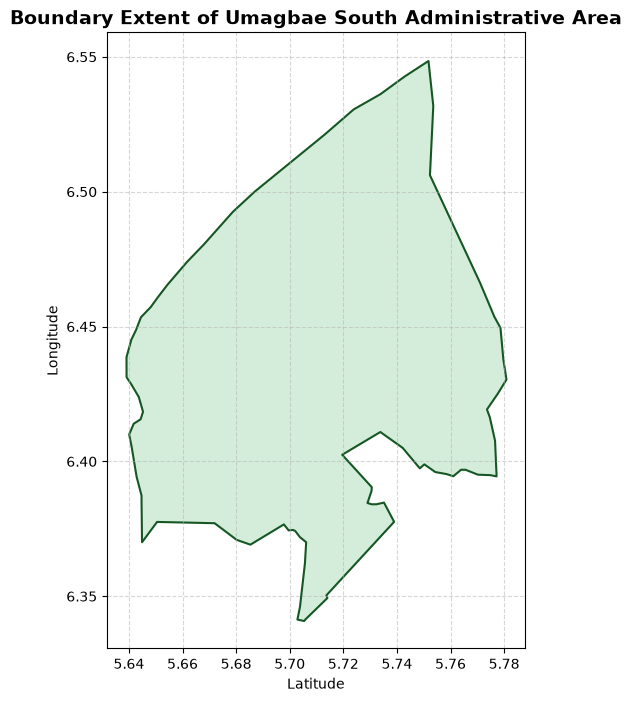

In [7]:
# PLOT UMAGBAE SOUTH ADMINISTRATIVE AREA POLYGON
fig, ax = plt.subplots(figsize=(8, 8))

ward_boundaries['geometry'].plot(ax=ax, color='#D4EDDA', edgecolor='#155724', linewidth=1.5)

ax.set_title("Boundary Extent of Umagbae South Administrative Area", fontsize=14, fontweight='bold')
ax.set_ylabel("Longitude")
ax.set_xlabel("Latitude")
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
# PLOT INTERACTIVE MAP OF UMAGBAE SOUTH ADMINISTRATIVE AREA USING OPENSTREETMAP POSITRON AS THE BASE MAP

# Convert coordinate system to Minna / WGS 84.
ward_boundaries = ward_boundaries.to_crs("EPSG:4326")

umagbae_south_interactive_webmap = ward_boundaries.explore(
    tooltip=["wardname", "lganame", "statename"],  # type: ignore
    tooltip_kwds={
        "aliases": ["Ward", "Local Government Area", "State"]
    },

    style_kwds={
        "fillColor": "transparent",  # No polygon fill
        "fillOpacity": 0.6,        # Keeps it transparent enough to see the base map
        "color": "#D35400",      # Dark orange border so the boundaries pop out
        "weight": 1.5
    },

    highlight_kwds={
        "fillColor": "transparent",  # Keep the polygon fill transparent on hover
        "fillOpacity": 0.8,        # Becomes more solid
        "color": "#D35400",      # Border turns deep rust orange
        "weight": 3                # Border line thickens
    }
)

# Initialize the Draw plugin to allow for interactive clipping and add it to the interactive map
Draw(
    export=True,
    filename="custom_aoi.geojson",
    position="topleft",
    draw_options={
        "polyline": False,
        "polygon": {
            "allowIntersection": False,
            "showArea": True,
            "shapeOptions": {"color": "#007A78", "fillOpacity": 0.2}
        },
        "rectangle": False,
        "circle": False,
        "marker": False,
        "circlemarker": False
    },
    edit_options={"edit": True, "remove": True}
).add_to(umagbae_south_interactive_webmap)

In [9]:
umagbae_south_interactive_webmap

In [10]:
# Create a shapefile of the custom area of interest (AOI) drawn on the interactive map
file_path = resolved_config.dataset.raw_dataset.aoi_geojson

# Read the custom AOI GeoJSON file and save it as a shapefile
custom_aoi = gpd.read_file(file_path)

# check if the GeoDataFrame is empty
if custom_aoi.empty:
    raise ValueError("The custom AOI GeoDataFrame is empty. Please ensure that the AOI has been drawn and saved correctly.")

# set the coordinate reference system (CRS) to WGS 84 (EPSG:4326)
custom_aoi = custom_aoi.set_crs("EPSG:4326")

# transform drawn polygons to valid polygon features
custom_aoi["geometry"] = custom_aoi.geometry.make_valid()
custom_aoi = custom_aoi[
    custom_aoi.geometry.type.isin(["Polygon", "MultiPolygon"])
].copy() 

# check if the GeoDataFrame is still empty after filtering
if custom_aoi.empty:
    raise ValueError("The custom AOI GeoDataFrame is empty after filtering for valid polygons. Please ensure that the AOI has been drawn correctly.")

# combine polygons into a single geometry if there are multiple polygons
# although this is not nevessaru in this case but as a precautionary measure
custom_aoi = custom_aoi.dissolve().reset_index(drop=True)

# add some attributes to the custom AOI GeoDataFrame
custom_aoi['id'] = 1
custom_aoi['name'] = "Custom Area of Interest"

# save shapefile 
shapefile_path = Path(resolved_config.dataset.processed_dataset.aoi_shapefile)
shapefile_path.parent.mkdir(parents=True, exist_ok=True)
custom_aoi.to_file(shapefile_path, driver="ESRI Shapefile", encoding="utf-8")

Text(53.722222222222214, 0.5, 'Latitude')

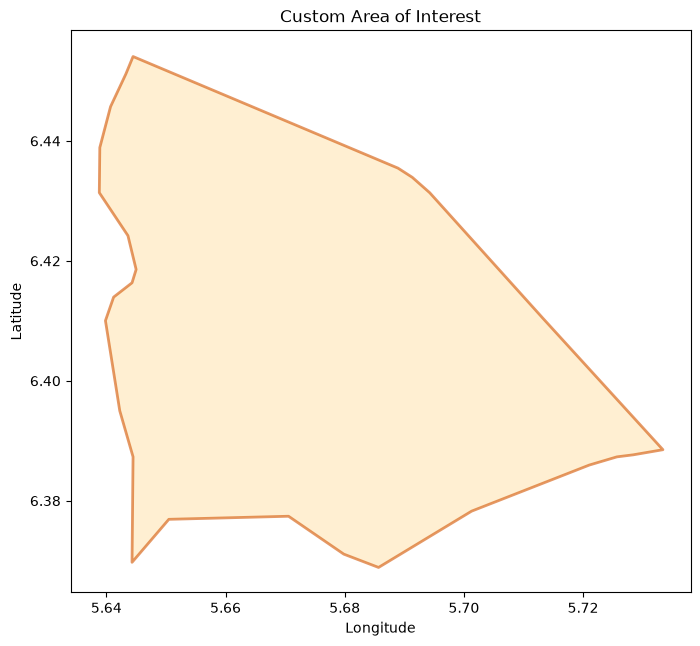

In [11]:
# Read and visualize custom area of interest shapefile
custom_aoi_shp = gpd.read_file(shapefile_path)

ax = custom_aoi_shp.plot(
    figsize=(8, 8),
    color="#FFE5B4",
    edgecolor="#D35400",
    linewidth=2,
    alpha=0.6,
)

ax.set_title("Custom Area of Interest")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [12]:
# Overlay custom shapefile on Openstreetmap
custom_aoi_webmap = custom_aoi_shp.to_crs("EPSG:4326").explore(
    tooltip=["id", "name"], # type: ignore
    style_kwds={
        "fillColor": "#FFE5B4",
        "fillOpacity": 0.6,
        "color": "#D35400",
        "weight": 2,
    },
    highlight_kwds={
        "fillColor": "#FF8C00",
        "fillOpacity": 0.8,
        "weight": 3,
    },
)

custom_aoi_webmap